<a href="https://colab.research.google.com/github/Andreina-A/Data620/blob/main/Week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Andreina Arias
<br>Week 6 assignment
<br>Here is a dataset that shows a simple 2-node network:  the attendance of 18 Southern Women at 14 social events:

Brief Description. Small “musty” datasets like that from this 1941 study have proven very valuable in testing and comparing new network algorithms.
Dataset.
Python code to create dataset: https://networkx.github.io/documentation/stable/auto_examples/algorithms/plot_davis_club.html
What can you infer about the relationships between (1) the women, and (2) the social events?  

Biadjacency matrix
<Compressed Sparse Row sparse array of dtype 'int64'
	with 89 stored elements and shape (18, 14)>
  Coords	Values
  (0, 0)	1
  (0, 1)	1
  (0, 2)	1
  (0, 3)	1
  (0, 4)	1
  (0, 5)	1
  (0, 7)	1
  (0, 8)	1
  (1, 0)	1
  (1, 1)	1
  (1, 2)	1
  (1, 4)	1
  (1, 5)	1
  (1, 6)	1
  (1, 7)	1
  (2, 1)	1
  (2, 2)	1
  (2, 3)	1
  (2, 4)	1
  (2, 5)	1
  (2, 6)	1
  (2, 7)	1
  (2, 8)	1
  (3, 0)	1
  (3, 2)	1
  :	:
  (12, 7)	1
  (12, 8)	1
  (12, 9)	1
  (12, 11)	1
  (12, 12)	1
  (12, 13)	1
  (13, 5)	1
  (13, 6)	1
  (13, 8)	1
  (13, 9)	1
  (13, 10)	1
  (13, 11)	1
  (13, 12)	1
  (13, 13)	1
  (14, 6)	1
  (14, 7)	1
  (14, 9)	1
  (14, 10)	1
  (14, 11)	1
  (15, 7)	1
  (15, 8)	1
  (16, 8)	1
  (16, 10)	1
  (17, 8)	1
  (17, 10)	1

#Friends, Member
17 Evelyn Jefferson
15 Laura Mandeville
17 Theresa Anderson
15 Brenda Rogers
11 Charlotte McDowd
15 Frances Anderson
15 Eleanor Nye
16 Pearl Oglethorpe
17 Ruth DeSand
17 Verne Sanderson
16 Myra Liddel
16 Katherina Rogers
17 Sylvia Avondale
17 Nora Fayette
1

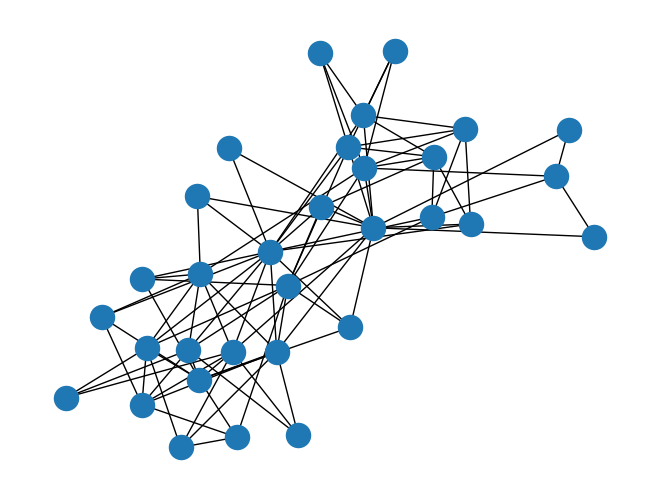

In [10]:
import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms import bipartite
from networkx.algorithms.community import greedy_modularity_communities

#code obtained from networkx website to import the dataset

G = nx.davis_southern_women_graph()
women = G.graph["top"]
clubs = G.graph["bottom"]

print("Biadjacency matrix")
print(bipartite.biadjacency_matrix(G, women, clubs))

# project bipartite graph onto women nodes
W = bipartite.projected_graph(G, women)
print()
print("#Friends, Member")
for w in women:
    print(f"{W.degree(w)} {w}")

# project bipartite graph onto women nodes keeping number of co-occurrence
# the degree computed is weighted and counts the total number of shared contacts
W = bipartite.weighted_projected_graph(G, women)
print()
print("#Friend meetings, Member")
for w in women:
    print(f"{W.degree(w, weight='weight')} {w}")

pos = nx.spring_layout(G, seed=648)  # Seed layout for reproducible node positions
nx.draw(G, pos)
plt.show()

##**Relationship between the women**
<br>Women are connected if they attended the same event

In [3]:
women_prejection= bipartite.weighted_projected_graph(G,women)
print("Women Projection Edges:", women_prejection.number_of_edges())

Women Projection Edges: 139


Looked into most cental women

In [4]:
centrality = nx.degree_centrality(women_prejection)#degree centraility for women in a bipartite network
sorted_centrality = sorted(centrality.items(), key=lambda x: x[1], reverse=True) #Sorted by descending of centrality

print("Most Central Women:")
for person in sorted_centrality[:5]: #top 5 only
    print(person)

Most Central Women:
('Evelyn Jefferson', 1.0)
('Theresa Anderson', 1.0)
('Ruth DeSand', 1.0)
('Verne Sanderson', 1.0)
('Sylvia Avondale', 1.0)


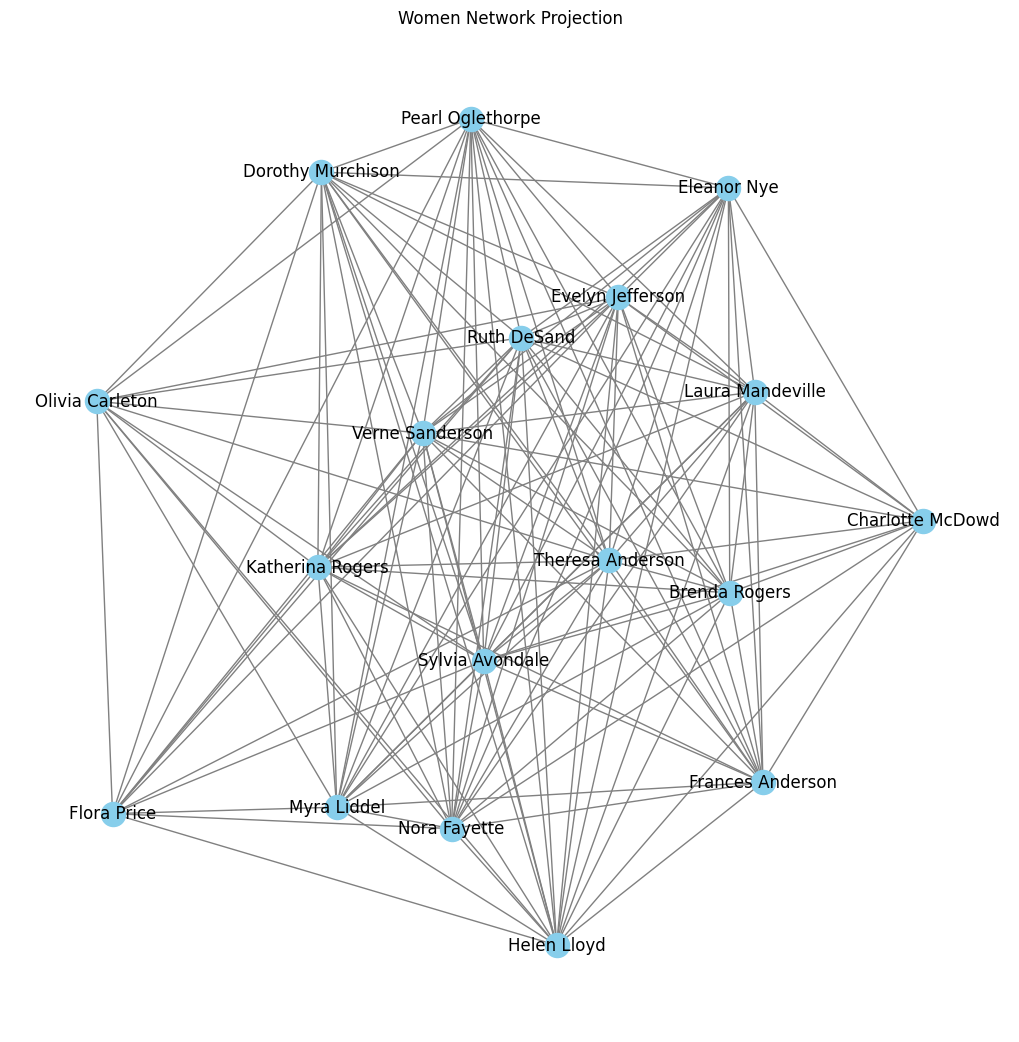

In [6]:
#Women Network graph
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(women_prejection, seed=48) #set seed for constant results
nx.draw(women_prejection, pos, with_labels=True, node_color= "skyblue", edge_color="grey", font_color="black")

plt.title("Women Network Projection")
plt.show()

##**Events Network**
<br>Events are connected if the same women attended both.

In [8]:
events_prejection= bipartite.weighted_projected_graph(G,clubs)
print("Event Projection Edges:", events_prejection.number_of_edges())


Event Projection Edges: 66


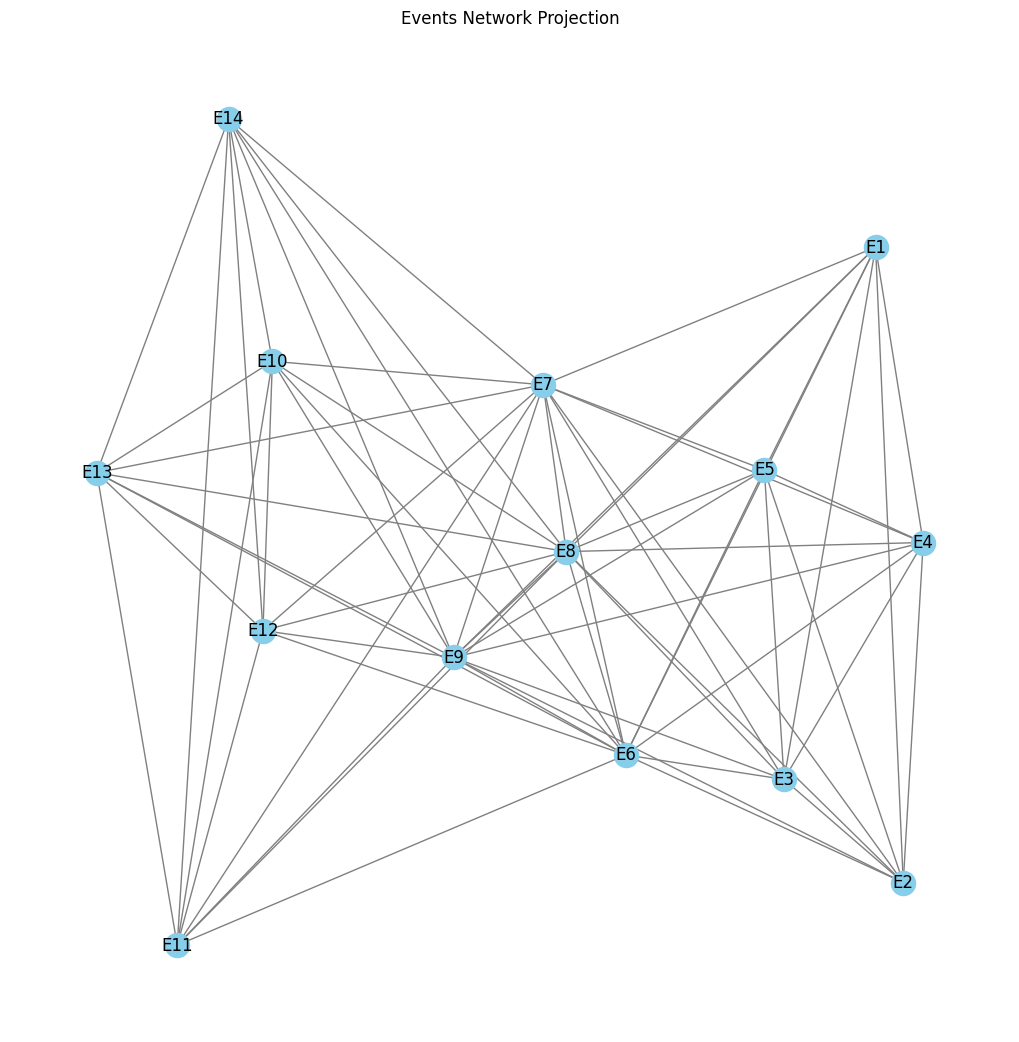

In [9]:
#Event Network graph
plt.figure(figsize=(10, 10))
pos=nx.spring_layout(events_prejection, seed=48)
nx.draw(events_prejection, pos, with_labels=True, node_color= "skyblue", edge_color="grey", font_color="black")

plt.title("Events Network Projection")
plt.show()

In [19]:
e_attendance= {club:G.degree(club) for club in clubs} #count how many women attend each event
sorted_e_attendance = sorted(e_attendance.items(), key=lambda x: x[1], reverse=True)#sort by descending order of attendance
for club, count in sorted_e_attendance[:5]:
    print(f"{club}: {count}")

E8: 14
E9: 12
E7: 10
E5: 8
E6: 8


###**Community Amoung Women**

In [13]:
communities=greedy_modularity_communities(women_prejection)
for i, c in enumerate(communities):
    print(f"Community {i+1}: ", list(c))

Community 1:  ['Olivia Carleton', 'Sylvia Avondale', 'Evelyn Jefferson', 'Myra Liddel', 'Theresa Anderson', 'Dorothy Murchison', 'Katherina Rogers', 'Nora Fayette', 'Helen Lloyd', 'Pearl Oglethorpe', 'Flora Price', 'Ruth DeSand']
Community 2:  ['Eleanor Nye', 'Brenda Rogers', 'Frances Anderson', 'Charlotte McDowd', 'Laura Mandeville', 'Verne Sanderson']


The analysis of the Southern Women dataset shows that attenance patterns reveal hidden social structures.
<br>What can you infer about the relationships between the women?
<br>Projecting the bipartite network onto women shows how often women attended the same events. The women formed two main social clusters, the women in the same cluster attended many of the same events, and a few women attended events across both clusters, acting as bridges. The most central women were Evelyn Jefferson, Theresa Anderson, Ruth DeSand', Verne Sanderson, and Sylvia Avondale with the highest centrality which are likely to attend many events, connect multiple women together and occupy central social positions.

<br>What can you infer about the relationships between the social events?
<br> Projecting onto events revealed which events share attendees. Events cluster also forms two groups, within a cluster share many of the same attendees, and some events had hight attendance, making them the central gathering point. The events with the highest attendance were E8, E9, and E7, making them central gathering points.